
# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP


## XOR Dataset

The XOR function produces 1 when the two input values are different, and 0 when they are the same.

| Input 1 | Input 2 | XOR Output |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# XOR input and output
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

print("X:")
print(X)
print("\ny:")
print(y)


d:\Languages & Tools\Python\lib\site-packages\google\api_core\_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

y:
[[0.]
 [1.]
 [1.]
 [0.]]


## 1. MLP Using Keras (TensorFlow High-Level API)

In [2]:

from tensorflow import keras
from tensorflow.keras import layers

keras_model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

keras_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 4)                 12        
                                                                 
 dense_1 (Dense)             (None, 1)                 5         
                                                                 
Total params: 17
Trainable params: 17
Non-trainable params: 0
_________________________________________________________________


In [3]:

history = keras_model.fit(
    X, y,
    epochs=1000,
    verbose=0
)

print("Training completed.")
print(f"Final loss: {history.history['loss'][-1]:.6f}")
print(f"Final accuracy: {history.history['accuracy'][-1]:.4f}")


Training completed.
Final loss: 0.000688
Final accuracy: 1.0000


In [4]:

keras_probabilities = keras_model.predict(X, verbose=0)
keras_predictions = (keras_probabilities >= 0.5).astype(int)

print("Keras Predictions:")
for inputs, probability, prediction, actual in zip(
    X.astype(int), keras_probabilities.flatten(),
    keras_predictions.flatten(), y.astype(int).flatten()
):
    print(
        f"Input={inputs.tolist()} | "
        f"Probability={probability:.4f} | "
        f"Predicted={prediction} | Actual={actual}"
    )

keras_loss, keras_accuracy = keras_model.evaluate(X, y, verbose=0)
print(f"\nKeras accuracy: {keras_accuracy:.4f}")


Keras Predictions:
Input=[0, 0] | Probability=0.0001 | Predicted=0 | Actual=0
Input=[0, 1] | Probability=0.9994 | Predicted=1 | Actual=1
Input=[1, 0] | Probability=0.9992 | Predicted=1 | Actual=1
Input=[1, 1] | Probability=0.0013 | Predicted=0 | Actual=0

Keras accuracy: 1.0000


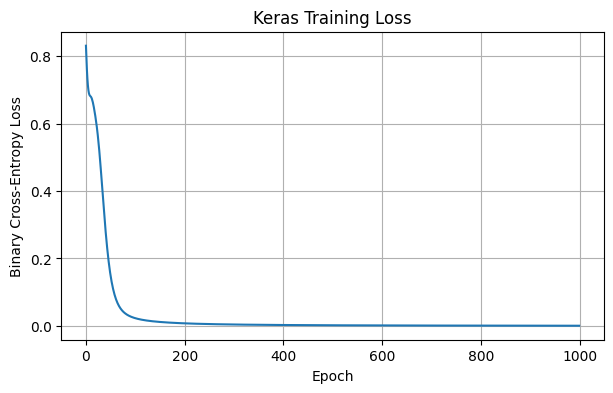

In [5]:

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Keras Training Loss")
plt.grid(True)
plt.show()


## 2. MLP Using TensorFlow Low-Level API

In [6]:

class XORMLP(tf.Module):
    def __init__(self, hidden_units=4):
        super().__init__()
        initializer = tf.keras.initializers.GlorotUniform(seed=42)

        self.W1 = tf.Variable(
            initializer(shape=(2, hidden_units)),
            trainable=True,
            name="W1"
        )
        self.b1 = tf.Variable(
            tf.zeros((hidden_units,)),
            trainable=True,
            name="b1"
        )
        self.W2 = tf.Variable(
            initializer(shape=(hidden_units, 1)),
            trainable=True,
            name="W2"
        )
        self.b2 = tf.Variable(
            tf.zeros((1,)),
            trainable=True,
            name="b2"
        )

    def __call__(self, x):
        hidden = tf.tanh(tf.matmul(x, self.W1) + self.b1)
        output = tf.sigmoid(tf.matmul(hidden, self.W2) + self.b2)
        return output


In [7]:

tf_model = XORMLP(hidden_units=4)

learning_rate = 0.05
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
loss_fn = tf.keras.losses.BinaryCrossentropy()

loss_history = []
accuracy_history = []

for epoch in range(1000):
    with tf.GradientTape() as tape:
        predictions = tf_model(X)
        loss = loss_fn(y, predictions)

    gradients = tape.gradient(
        loss,
        [tf_model.W1, tf_model.b1, tf_model.W2, tf_model.b2]
    )

    optimizer.apply_gradients(zip(
        gradients,
        [tf_model.W1, tf_model.b1, tf_model.W2, tf_model.b2]
    ))

    predicted_classes = tf.cast(predictions >= 0.5, tf.float32)
    accuracy = tf.reduce_mean(
        tf.cast(tf.equal(predicted_classes, y), tf.float32)
    )

    loss_history.append(float(loss))
    accuracy_history.append(float(accuracy))

print("Low-level TensorFlow training completed.")
print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Final accuracy: {accuracy_history[-1]:.4f}")


Low-level TensorFlow training completed.
Final loss: 0.000228
Final accuracy: 1.0000


In [8]:

tf_probabilities = tf_model(X).numpy()
tf_predictions = (tf_probabilities >= 0.5).astype(int)

print("TensorFlow Low-Level Predictions:")
for inputs, probability, prediction, actual in zip(
    X.astype(int), tf_probabilities.flatten(),
    tf_predictions.flatten(), y.astype(int).flatten()
):
    print(
        f"Input={inputs.tolist()} | "
        f"Probability={probability:.4f} | "
        f"Predicted={prediction} | Actual={actual}"
    )

tf_accuracy = np.mean(tf_predictions == y.astype(int))
print(f"\nTensorFlow accuracy: {tf_accuracy:.4f}")


TensorFlow Low-Level Predictions:
Input=[0, 0] | Probability=0.0002 | Predicted=0 | Actual=0
Input=[0, 1] | Probability=0.9997 | Predicted=1 | Actual=1
Input=[1, 0] | Probability=0.9997 | Predicted=1 | Actual=1
Input=[1, 1] | Probability=0.0002 | Predicted=0 | Actual=0

TensorFlow accuracy: 1.0000


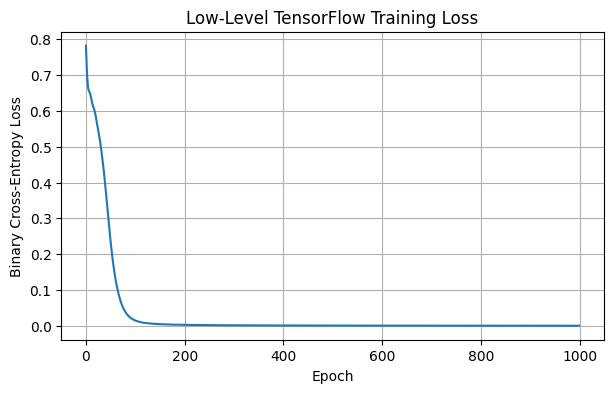

In [9]:

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Low-Level TensorFlow Training Loss")
plt.grid(True)
plt.show()


## 3. Hyperparameter Experiment

In [10]:

def build_and_train_keras(hidden_units=4, activation="tanh",
                          learning_rate=0.05, epochs=1000):
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(hidden_units, activation=activation),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(X, y, epochs=epochs, verbose=0)
    loss, accuracy = model.evaluate(X, y, verbose=0)

    return model, history, loss, accuracy


experiments = [
    {"hidden_units": 2, "activation": "tanh", "learning_rate": 0.05, "epochs": 1000},
    {"hidden_units": 4, "activation": "tanh", "learning_rate": 0.05, "epochs": 1000},
    {"hidden_units": 8, "activation": "tanh", "learning_rate": 0.05, "epochs": 1000},
    {"hidden_units": 4, "activation": "relu", "learning_rate": 0.05, "epochs": 1000},
    {"hidden_units": 4, "activation": "tanh", "learning_rate": 0.01, "epochs": 1000},
]

results = []

for config in experiments:
    _, _, loss, accuracy = build_and_train_keras(**config)
    results.append({
        **config,
        "final_loss": loss,
        "accuracy": accuracy
    })

for result in results:
    print(result)


{'hidden_units': 2, 'activation': 'tanh', 'learning_rate': 0.05, 'epochs': 1000, 'final_loss': 0.0005917575326748192, 'accuracy': 1.0}
{'hidden_units': 4, 'activation': 'tanh', 'learning_rate': 0.05, 'epochs': 1000, 'final_loss': 0.00017788916011340916, 'accuracy': 1.0}
{'hidden_units': 8, 'activation': 'tanh', 'learning_rate': 0.05, 'epochs': 1000, 'final_loss': 8.40499997138977e-05, 'accuracy': 1.0}
{'hidden_units': 4, 'activation': 'relu', 'learning_rate': 0.05, 'epochs': 1000, 'final_loss': 0.0004110627924092114, 'accuracy': 1.0}
{'hidden_units': 4, 'activation': 'tanh', 'learning_rate': 0.01, 'epochs': 1000, 'final_loss': 0.00533897103741765, 'accuracy': 1.0}


## 4. Decision Boundary for the Keras Model

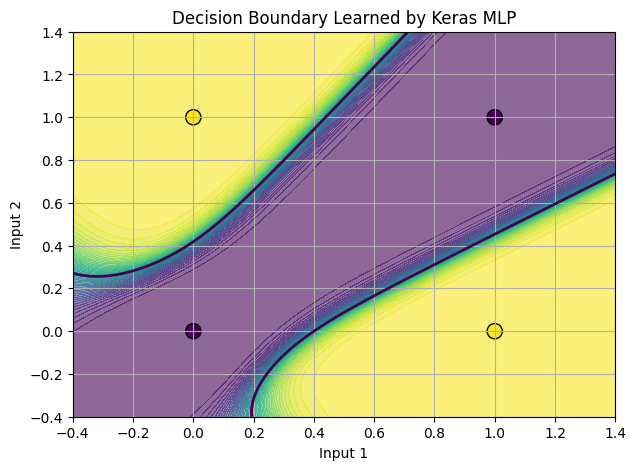

In [11]:

def plot_decision_boundary(model, X, y, title):
    margin = 0.4
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    probabilities = model.predict(grid, verbose=0).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, probabilities, levels=50, alpha=0.6)
    plt.contour(xx, yy, probabilities, levels=[0.5], linewidths=2)
    plt.scatter(
        X[:, 0], X[:, 1],
        c=y.flatten(),
        edgecolors="black",
        s=120
    )
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.title(title)
    plt.grid(True)
    plt.show()


plot_decision_boundary(
    keras_model, X, y,
    "Decision Boundary Learned by Keras MLP"
)



## 5. Comparison and Discussion

### Effect of the number of neurons
A hidden layer with at least two neurons is sufficient in principle for learning XOR. Increasing the number of neurons generally gives the model more capacity, although too many neurons are unnecessary for this tiny dataset.

### Effect of activation function
XOR is a non-linear problem, so the hidden layer must introduce non-linearity. `tanh` generally works very well on this small, symmetric dataset. `ReLU` can also solve XOR, but its optimization behavior can depend more strongly on initialization and learning rate.

### Effect of learning rate
A very small learning rate can make training slow, while a very large learning rate can make optimization unstable. A moderate value such as `0.05` works well for this demonstration.

### Effect of epochs
Because the XOR dataset contains only four examples, the model can converge quickly. More epochs give the optimizer additional opportunities to minimize the loss, but excessive epochs are not necessary.

### Keras vs. low-level TensorFlow
Keras provides a concise high-level API for defining, compiling, training, and evaluating neural networks. Low-level TensorFlow provides more direct control over variables, gradient computation, and parameter updates through `tf.GradientTape`.

## Conclusion

The MLP successfully learns the XOR Boolean function by using a hidden layer with a non-linear activation function. Unlike a single-layer perceptron, an MLP can learn the non-linear decision boundary required by XOR. The experiment also demonstrates how learning rate, activation function, number of neurons, and epochs influence training.
